In [222]:

import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.sparse import coo_matrix, csc_matrix
from numbers import Number
import numpy as np
import scipy
from scipy.sparse import csc_matrix, dia_matrix
from typing import Literal, Tuple, Callable
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import RectBivariateSpline
import linear_solver

np.set_printoptions(linewidth=np.inf)
np.set_printoptions(precision=3, suppress=True)

In [343]:
%pdb off

NameError: name 'num_cells' is not defined

In [711]:


class NavierStokesSolver:
    
    scheme              : Literal["central_difference", "upwind", "hybrid"]

    L_x                 : float
    L_y                 : float
    L                   : float | None
    n_rows              : int
    n_cols              : int
    phi_B               : float
    gamma               : float
    error               : float
    
    # if u is None
    u_B                 : dict
    v_B                 : dict
    B                   : dict
    
    kinematic_viscosity : float
    mass_density        : float
    Re                  : float
    
    alpha_m             : float
    alpha_p             : float
    
    A                   : dict
    b                   : dict
    x                   : dict
    
    _constructor_args_  : dict
    
    A_diag              : dia_matrix
    
    def __init__(
        
        self, 
        scheme: Literal["central_difference", "upwind", "hybrid"] = "central_difference",
        L_x         : float = 1,
        L_y         : float = 1,
        L           : float | None = None,
        n_rows      : int = 50,
        n_cols      : int = 50,
        phi_Bw      : float = 100,
        phi_Be      : float = 0,
        phi_Bs      : float = 0,
        phi_Bn      : float = 100,
        gamma       : float = 1,
        u           : Tuple[Number | Callable] | None = None,
        
        # if u is None, we know to solve for a velocity field as well
        u_Bw        : float = 0,
        u_Be        : float = 0,
        u_Bs        : float = 0,
        u_Bn        : float = 1,
        v_Bw        : float = 0,
        v_Be        : float = 0,
        v_Bs        : float = 0,
        v_Bn        : float = 0,

        kinematic_viscosity : float = None,
        Re                  : float = 100,
        mass_density        : float = 1,
        alpha_m             : float = 0.8,
        alpha_p             : float = 0.3
        
        ):
        
        self._constructor_args_ = {key: val for key, val in locals().items() if key != 'self'}
        
        self.L_x        = L_x
        self.L_y        = L_y
        self.n_rows     = n_rows
        self.n_cols     = n_cols
        self.delta_x    = self.L_x / self.n_cols
        self.delta_y    = self.L_y / self.n_rows
        self.has_vel    = u is not None
        self.scheme     = scheme
        self.alpha_m    = alpha_m
        self.alpha_p    = alpha_p
        
        self.A = { '\phi': None, 'm': None, "p\'": None }
        self.b = { '\phi': None, 'u': None, 'v': None, "p\'": None }
        self.x = { '\phi': None, 'u': None, 'v': None, 'u_f': None, 'v_f': None, 's': None, "p\'": None,"p": None }
        self.A_diag = dia_matrix((self.n_rows * self.n_cols, self.n_rows * self.n_cols))

        self.u_B        = { 'n': u_Bn, 's': u_Bs, 'e': u_Be, 'w': u_Bw }
        self.v_B        = { 'n': v_Bn, 's': v_Bs, 'e': v_Be, 'w': v_Bw }
        self.phi_B      = { 'w': phi_Bw, 'e': phi_Be, 'n': phi_Bn, 's': phi_Bs }
        self.B          = { 'u': self.u_B, 'v': self.v_B, '\phi': self.phi_B }
        
        self.x['u_f']   = np.zeros((self.n_rows + 2, self.n_cols + 1))
        self.x['v_f']   = np.zeros((self.n_rows + 1, self.n_cols + 2))        
        self.x['u']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
        self.x['v']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
        self.x['s']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
        
        self.gamma      = gamma
        
        if u is None: # We need to solve for velocity fields
            
            assert(L is not None)
            self.L      = L
            self.L_x    = L
            self.L_y    = L
            
            assert(bool(kinematic_viscosity) != bool(Re))
                    
            self.kinematic_viscosity    = kinematic_viscosity if kinematic_viscosity else u_Bn * L / Re
            self.mass_density           = mass_density
            self.Re                     = Re if Re else u_Bn * L / kinematic_viscosity
            self.gamma                  = 1/self.Re
            
            # set velocity boundary conditions
            
            self.x['u_f'][0, :]                 = self.B['u']['n']
            self.x['u_f'][self.n_rows + 1, :]   = self.B['u']['s']
            self.x['u_f'][:, self.n_cols]       = self.B['u']['e']
            self.x['u_f'][:, 0]                 = self.B['u']['w']
            
            self.x['v_f'][0, :]                 = self.B['v']['n']
            self.x['v_f'][self.n_rows, :]       = self.B['v']['s']
            self.x['v_f'][:, self.n_cols + 1]   = self.B['v']['e']
            self.x['v_f'][:, 0]                 = self.B['v']['w']
            
        else: # Use the known velocityy field to construct a matrix storing face velocities (giving convective link coefficients)
            
            uxf = lambda i, j : u[0] if isinstance(u[0], int) else u[0](j * self.delta_x, ((self.n_rows + 1) - i - 1)*self.delta_y)   
            uyf = lambda i, j : u[1] if isinstance(u[1], int) else u[1](j * self.delta_x, ((self.n_rows + 1) - i - 1)*self.delta_y) 
              
            for i in range(self.n_rows + 2):
                for j in range(self.n_cols+1):
                    self.x['u_f'][i,j] = uxf(i, j)
            for i in range(self.n_rows + 1):
                for j in range(self.n_cols + 2):
                    self.x['v_f'][i,j] = uyf(i, j)
            
            for i in range(1, self.n_rows+1):
                for j in range(1, self.n_cols + 1):
                    self.x['u'][i,j] = uxf(i+ self.delta_y, j + self.delta_x)
                    self.x['v'][i,j] = uyf(i+ self.delta_y, j + self.delta_x)
                    
            self.x['s'] = np.sqrt(self.x['u']**2 + self.x['v']**2)
                  
        # diffusive link coefficients
        self.D = {
            'w': self._area_('w') * self.gamma / self.delta_y,
            'e': self._area_('e') * self.gamma / self.delta_y,
            'n': self._area_('n') * self.gamma / self.delta_x,
            's': self._area_('s') * self.gamma / self.delta_x,
        }
        
        self.A['\phi'] = {
                'p': np.zeros((self.n_rows + 2, self.n_cols + 2)),
                'e': np.zeros((self.n_rows + 2, self.n_cols + 2)),
                'w': np.zeros((self.n_rows + 2, self.n_cols + 2)),
                's': np.zeros((self.n_rows + 2, self.n_cols + 2)),
                'n': np.zeros((self.n_rows + 2, self.n_cols + 2)),
            }
        
        # set the solution boundary (Dirichlet)
        
        self.x['\phi']                                       = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
        self.x['\phi'][0, 1: self.n_cols + 1]                = self.B['\phi']['n']
        self.x['\phi'][self.n_rows + 1, 1: self.n_cols + 1]  = self.B['\phi']['s']
        self.x['\phi'][:, self.n_cols + 1]                   = self.B['\phi']['e']
        self.x['\phi'][:, 0]                                 = self.B['\phi']['w']
        self.b['\phi']                                       = np.zeros((self.n_rows + 2,  self.n_cols + 2))

        if u is None: # Set the link_coefficient matrices and guess the solutions
            
            # guess the velocity field solution
            self.A['m'] = {
                'p': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'e': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'w': np.ones((self.n_rows + 2, self.n_cols + 2)),
                's': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'n': np.ones((self.n_rows + 2, self.n_cols + 2)),
            }
            self.A['p\''] = {
                'p': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'e': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'w': np.ones((self.n_rows + 2, self.n_cols + 2)),
                's': np.ones((self.n_rows + 2, self.n_cols + 2)),
                'n': np.ones((self.n_rows + 2, self.n_cols + 2)),
            }

            self.x['p']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
            self.x["p\'"]   = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
            
            self.b['u']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
            self.b['v']     = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
            self.b["p\'"]   = np.zeros(((self.n_rows + 2), (self.n_cols + 2)))
            
            # setting the solution boundary
            
            self.x['u'][0, 1: self.n_cols + 1]                      = self.B['u']['n']
            self.x['u'][self.n_rows +1, 1: self.n_cols + 1]         = self.B['u']['s']
            self.x['u'][:, self.n_cols + 1]                         = self.B['u']['e']
            self.x['u'][:, 0]                                       = self.B['u']['w']
            
            self.x['v'][0, 1:self.n_cols + 1]                       = self.B['v']['n']
            self.x['v'][self.n_rows + 1, 1: self.n_cols + 1]        = self.B['v']['s']
            self.x['v'][:, self.n_cols + 1]                         = self.B['v']['e']
            self.x['v'][:, 0]                                       = self.B['v']['w']
            
            # setting the pressure link coefficients

    def solve(self, objective: Literal['\phi', 'm'] ='\phi', solveSparse=True, tolerance=0.01, max_iter=10_000, threshold=1e-3):
        
        if objective == '\phi':
            self._construct_problem_(objective='\phi')
            return self._solve_jacobi_(objective='\phi', tolerance=tolerance, max_iter=max_iter) if not solveSparse else self._solve_sparse_(objective='\phi')

        # no velocity field given, must first solve three separate FVM problems
        # one for u, v and p
        # and only then can the problem for \phi

        err = np.inf
        i = 0
        while err > threshold:

            u_prev = self.x['u'].copy()
            v_prev = self.x['v'].copy()
            
            self._construct_problem_(objective='m')
            
            # self.b['u'][1:-1, 1:-1] += -self._p_src_('u')
            # self.b['v'][1:-1, 1:-1] += -self._p_src_('v')
            
            self._solve_sparse_(objective='u') if solveSparse else self._solve_jacobi_(objective='u', tolerance=tolerance, max_iter=max_iter)
            self._solve_sparse_(objective='v') if solveSparse else self._solve_jacobi_(objective='v', tolerance=tolerance, max_iter=max_iter)
            
            self._interp_face_v_()
            self._construct_problem_(objective="p\'")
            self._solve_sparse_(objective="p\'") if solveSparse else self._solve_jacobi_(objective='p\'', tolerance=tolerance, max_iter=max_iter)
            
            self._correct_p_()
            self._correct_cell_v_()
            self._correct_face_v_()
            
            self.x['s'] = np.sqrt(self.x['u']**2 + self.x['v']**2)
            
            p_err = np.linalg.norm(self.x["p\'"])
            u_err = np.linalg.norm(self.x['u'] - u_prev)
            v_err = np.linalg.norm(self.x['v'] - v_prev)
            
            err = u_err + v_err + p_err
            print(f"\rIteration: {i}, u_err: {u_err}, v_err: {v_err}, p_corr_err: {p_err}", sep='', end='')
            
            i+=1
        
        print(f"\nFinished with total error {err}")
        return self.x['u'], u_err, self.x['v'], v_err, self.x['p'], p_err
            
    def plot(self, 
             objective          : Literal['\phi', 'u', 'v', 'p']='\phi', 
             num_contours       : int = 40, 
             name               : str = None, 
             save               : bool = False,
             v_field_str        : Tuple[str, str] = None, 
             figsize            : int = 5,  
             num_streamlines    : int = 10
             ):
        
        core = self.x[objective][1:-1, 1:-1][::-1] if objective else None
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(2 * figsize if objective and num_streamlines else int(1.5 * figsize), figsize))
                    
        x_points = np.arange(0, self.n_cols)
        y_points = np.arange(0, self.n_rows)

        X, Y = np.meshgrid(x_points, y_points)
        
        u = self.x['u'][1:-1, 1:-1][::-1]
        v = self.x['v'][1:-1, 1:-1][::-1]
        
        if objective:
            assert(num_contours > 0)
            contour = ax.contourf(X, Y, core, levels=num_contours, cmap='jet' if not num_streamlines else 'bone')
            fig.colorbar(contour, ax=ax).ax.set_title(label=f'${objective}$')
                
            if num_streamlines:
                streamplot = plt.streamplot(X, Y, u, v, density=1.5, linewidth=1, color=np.sqrt(u**2 + v**2), arrowsize=1, cmap='jet')
                fig.colorbar(streamplot.lines, ax=ax).ax.set_title(label=f'$s$')
                
        else:
            assert(num_streamlines > 0)
            streamplot = plt.streamplot(X, Y, u, v, density=1.5, linewidth=1, color=np.sqrt(u**2 + v**2), arrowsize=1, cmap='jet')
            fig.colorbar(streamplot.lines, ax=ax).ax.set_title(label=f'$s$')
                        
        # Set axis ticks
        ax.set_xticks([0, self.n_cols-1])
        ax.set_xticklabels([0, self.L_x], rotation=0)
        ax.set_yticks([0, self.n_rows-1])
        ax.set_yticklabels([0, self.L_y], rotation=0)
        ax.set_ylim(ymin=0, ymax=self.n_rows-1)
        ax.set_xlim(xmin=0, xmax=self.n_cols-1)

        if objective in self.B.keys() and self.B[objective]:
            # TOP (in figure coordinates)
            ax.text(0.5, 1.05, f'${objective}_B = {self.B[objective]["n"]}$', 
                    ha='center', va='center', transform=ax.transAxes, fontsize=12, weight='bold') 

            # BOTTOM (in figure coordinates)
            ax.text(0.5, -0.05, f'${objective}_B = {self.B[objective]["s"]}$', 
                    ha='center', va='center', transform=ax.transAxes, fontsize=12, weight='bold')  

            # LEFT (in figure coordinates)
            ax.text(-0.05, 0.5, f'${objective}_B = {self.B[objective]["w"]}$', 
                    ha='center', va='center', rotation=90, transform=ax.transAxes, fontsize=12, weight='bold') 

            # RIGHT (in figure coordinates)
            ax.text(1.03, 0.5, f'${objective}_B = {self.B[objective]["e"]}$', 
                    ha='center', va='center', rotation=90, transform=ax.transAxes, fontsize=12, weight='bold') 


        if v_field_str:
            ax.text(0, -0.1, f'${{\\bf u}} = \\langle {v_field_str[0]}, {v_field_str[1]} \\rangle$' , 
                    ha='center', va='center', transform=ax.transAxes, fontsize=12, weight='bold')  
        
        #Residual text (in figure coordinates)
        ax.text(1, -0.1, f'$L^2 Residual = {np.round(self.error, 4)}$', 
                ha='center', va='center', transform=ax.transAxes, fontsize=12, weight='bold')  

        if save:
            plt.savefig(name, dpi=300, bbox_inches="tight")
        
        plt.show()

    def order_conv(self, exact_res: float = 320, coarse_res: float = 80, fine_res: float = 160, objective: Literal['\phi', 'uvp'] ='\phi') -> float:

        exact_solver = NavierStokesSolver(**{**self._constructor_args_, 'n_cols': exact_res, 'n_rows': exact_res})
        coarse_solver = NavierStokesSolver(**{**self._constructor_args_, 'n_cols': coarse_res, 'n_rows': coarse_res})
        fine_solver = NavierStokesSolver(**{**self._constructor_args_, 'n_cols': fine_res, 'n_rows': fine_res})
        
        if objective == '\phi':
            x_coarse, _ = coarse_solver.solve('\phi')
            x_fine, _ = fine_solver.solve('\phi')
            x_exact, _ = exact_solver.solve('\phi')
            return self._get_order_(x_coarse[1:-1, 1:-1], x_fine[1:-1, 1:-1], x_exact[1:-1, 1:-1], coarse_res, fine_res, exact_res)
        
        elif objective == 'uvp':
            x_coarses = coarse_solver.solve('m')
            x_fines = fine_solver.solve('m')
            x_exacts = exact_solver.solve('m')
            
            o = [None, None, None]
            for i in range(3):
                x_coarse = x_coarses[2*i]
                x_fine = x_fines[2*i]
                x_exact = x_exacts[2*i]
                o[i] = self._get_order_(x_coarse[1:-1, 1:-1], x_fine[1:-1, 1:-1], x_exact[1:-1, 1:-1], coarse_res, fine_res, exact_res)
            return o

    def _get_order_(self, x_coarse, x_fine, x_exact, coarse_res, fine_res, exact_res) -> float:
        
        linsp_coarse = np.linspace(0, 1, coarse_res)
        linsp_fine = np.linspace(0, 1, fine_res)
        linsp_exact = np.linspace(0, 1, exact_res)

        x_coarse_interpolator = RectBivariateSpline(linsp_coarse, linsp_coarse, x_coarse)

        x_coarse_interp = x_coarse_interpolator(linsp_exact, linsp_exact)

        x_fine_interpolator = RectBivariateSpline(linsp_fine, linsp_fine, x_fine)

        x_fine_interp = x_fine_interpolator(linsp_exact, linsp_exact)

        err_coarse = np.linalg.norm(x_exact - x_coarse_interp) / coarse_res
        err_fine = np.linalg.norm(x_exact - x_fine_interp) / fine_res

        O = (np.log(np.abs(err_coarse / err_fine))) / (np.log((1 / coarse_res) / (1 / fine_res)))
        
        return O

    def _construct_problem_(self, objective: Literal["\phi", "m", "p\'"] = "\phi"):

        if objective == 'p\'':
            self._p_corr_coeffs_()
            return
        
        b_e, b_w, b_n, b_s = None, None, None, None
        if self.scheme == "central_difference":
            b_e, b_w, b_n, b_s = self._scalar_coeff_cd_(
                self.A[objective]['p'],
                self.A[objective]['e'],
                self.A[objective]['w'],
                self.A[objective]['n'],
                self.A[objective]['s']
                )
        elif self.scheme == 'upwind':
            b_e, b_w, b_n, b_s = self._scalar_coeff_upwind_(
                self.A[objective]['p'],
                self.A[objective]['e'],
                self.A[objective]['w'],
                self.A[objective]['n'],
                self.A[objective]['s']
                )
        elif self.scheme == 'hybrid':
            b_e, b_w, b_n, b_s = self._scalar_coeff_hybrid_(
                self.A[objective]['p'],
                self.A[objective]['e'],
                self.A[objective]['w'],
                self.A[objective]['n'],
                self.A[objective]['s']
                )
            
        if objective == '\phi':
            self._scalar_src_(b_e, b_w, b_n, b_s, self.b['\phi'], self.B['\phi'])
        else:
            self._scalar_src_(b_e, b_w, b_n, b_s, self.b['u'], self.B['u'])
            self._scalar_src_(b_e, b_w, b_n, b_s, self.b['v'], self.B['v'])
            
            self.b['u'][1:-1, 1:-1] -= self._p_src_('u')
            self.b['v'][1:-1, 1:-1] -= self._p_src_('v')
            
            self.A['m']['p'][1:-1, 1:-1] /= self.alpha_m
            self.b['u'][1:-1, 1:-1] += (1 - self.alpha_m) * self.A['m']['p'][1:-1, 1:-1] * self.x['u'][1:-1, 1:-1]
            self.b['v'][1:-1, 1:-1] += (1 - self.alpha_m) * self.A['m']['p'][1:-1, 1:-1] * self.x['v'][1:-1, 1:-1]
            
        
            
        # for i in range(1, self.n_rows+1):
        #     for j in range(1, self.n_cols+1):

        #         coeffs = self._get_coeffs_(i=i, j=j, objective=objective)
        #         self._set_arrays_(
        #             *coeffs, 
        #             i=i, j=j,
        #             objective=objective
        #         )
                                         
    def _get_coeffs_(self, 
        i,j,
        objective: Literal["\phi", "m"] = "\phi"
        ):
            
        a_nb = {'w': 0, 'e': 0, 'n': 0, 's': 0}
        S_terms = {'w': 0, 'e': 0, 'n': 0, 's': 0}
        
        
        if self.scheme == "central_difference":
        
            for nbr in a_nb.keys():
                self._nbr_coeff_cd_(nbr, i,j, a_nb, S_terms)
            
        elif self.scheme == "upwind":
            
            for nbr in a_nb.keys():
                self._nbr_coeff_upwind_(nbr, i,j, a_nb, S_terms)
                
        elif self.scheme == "hybrid":
            
            for nbr in a_nb.keys():
                self._nbr_coeff_hybrid_(nbr, i,j, a_nb, S_terms)
                
        else:
            pass
        
        S_p = -sum([v for v in S_terms.values()])
        a_P = sum([a for a in a_nb.values()]) + self._f_('e', i, j) - self._f_('w', i, j) + self._f_('n', i, j) - self._f_('s', i, j) - S_p
        S_u = None
        
        if objective == '\phi':  
            
            S_u = sum([self.B[objective][face] * S_terms[face] for face in S_terms.keys()])
            
        else:
            
            S_u = [
                sum([self.B[o][face] * S_terms[face] for face in S_terms.keys()]) + \
                (1 - self.alpha_m) * (a_P / self.alpha_m) * self.x[o][i,j]  
                for o in ['u', 'v']]
            a_P /= self.alpha_m

        return a_P, a_nb['e'], a_nb['w'], a_nb['n'], a_nb['s'], S_u
            
    def _p_src_(self, objective):

        
        if objective == "u":
            return  (1/2) * (self.x['p'][1:-1, 2:] - self.x['p'][1:-1, 0:-2]) * self._area_('e') 
                    
        elif objective == "v":
            return (1/2) * (self.x['p'][0:-2, 1:-1] - self.x['p'][2:, 1:-1]) * self._area_('n')
        

    # def _mass_flux_(self):
    #     f_e = self._area_('e') * self.x['u_f'][1:-1, 1:]
    #     f_w = self._area_('w') * self.x['u_f'][1:-1, :-1]
    #     f_n = self._area_('n') * self.x['v_f'][1:, 1:-1]
    #     f_s = self._area_('s') * self.x['v_f'][:-1, 1:-1]
        
    #     return f_e - f_w + f_n - f_s
        
    def _set_arrays_(self, a_P, a_E, a_W, a_N, a_S, S_u, i, j, objective: Literal['\phi', 'm', 'p\'']='\phi'):
        
        self.A[objective]['p'][i, j] = np.float32(a_P)
        self.A[objective]['e'][i, j] = np.float32(a_E)
        self.A[objective]['w'][i, j] = np.float32(a_W)
        self.A[objective]['n'][i, j] = np.float32(a_N)
        self.A[objective]['s'][i, j] = np.float32(a_S)
              
        if objective != 'm':
            self.b[objective][i, j] = np.float32(S_u)
        else:
            self.b['u'][i, j] = np.float32(S_u[0])
            self.b['v'][i, j] = np.float32(S_u[1])
    
    # def _to_sparse__(self, a_E, a_W, a_N, a_S, a_P):
    #     nrows = self.n_rows
    #     ncols = self.n_cols
    #     num_cells = self.n_rows * self.n_cols

    #     data, row, col = [], [], []

    #     def index(i, j):
    #         return i * ncols + j

    #     for i in range(1, nrows+1):  
    #         for j in range(1, ncols+1): 

    #             center = index(i-1 , j-1)  

    #             # Central coefficient (diagonal)
    #             data.append(a_P[i, j])
    #             row.append(center)
    #             col.append(center)

    #             # East neighbor
    #             if j < ncols:  # Exclude right cells
    #                 data.append(-a_E[i, j])
    #                 row.append(center)
    #                 col.append(index((i-1), (j-1) + 1))

    #             # West neighbor
    #             if j > 1:  # Exclude left cells
    #                 data.append(-a_W[i, j])
    #                 row.append(center)
    #                 col.append(index((i-1), (j-1) - 1))

    #             # North neighbor
    #             if i > 1:  # Exclude top cells
    #                 data.append(-a_N[i, j])
    #                 row.append(center)
    #                 col.append(index((i-1) - 1, (j-1)))

    #             # South neighbor
    #             if i < nrows:  # Exclude bottom cells
    #                 data.append(-a_S[i, j])
    #                 row.append(center)
    #                 col.append(index((i-1) + 1, (j-1)))

    #     # Assemble into a sparse matrix
    #     A_coo = coo_matrix((data, (row, col)), shape=(num_cells, num_cells))
    #     return A_coo.tocsc()
    
    def _to_sparse_(self, a_E, a_W, a_N, a_S, a_P):
        nrows, ncols = self.n_rows, self.n_cols
        num_cells = nrows * ncols

        # Flatten all coefficients
        a_P_flat = a_P[1:-1, 1:-1].flatten()  # Center
        a_E_flat = a_E[1:-1, 1:-1].flatten()  # East
        a_W_flat = a_W[1:-1, 1:-1].flatten()  # West
        a_N_flat = a_N[1:-1, 1:-1].flatten()  # North
        a_S_flat = a_S[1:-1, 1:-1].flatten()  # South

        # Set diagonals directly (matrix flipped along horizontal)
        self.A_diag.setdiag(a_P_flat, k=0)                # Main diagonal
        self.A_diag.setdiag(-a_E_flat[:-1], k=1)          # East diagonal
        self.A_diag.setdiag(-a_W_flat[1:], k=-1)          # West diagonal
        self.A_diag.setdiag(-a_N_flat[ncols:], k=-ncols)  # North diagonal (flipped matrix means the coeff is to the left)
        self.A_diag.setdiag(-a_S_flat[:-ncols], k=ncols)  # South diagonal (flipped matrix means the coeff is to the right)

        # Convert to CSC format for solver compatibility
        return self.A_diag.tocsc()    
    
    def _clear_a_diag(self):
        
        nrows, ncols = self.n_rows, self.n_cols
        num_cells = nrows * ncols
        self.A_diag.setdiag(0, k=0) 
        self.A_diag.setdiag(0, k=1)    
        self.A_diag.setdiag(0, k=-1)     
        self.A_diag.setdiag(0, k=-ncols)  
        self.A_diag.setdiag(0, k=ncols)
            
    def _solve_sparse_(self, objective: Literal["\phi", "m", "p\'"] = "\phi") -> Tuple[np.ndarray, float] :
        
        o = 'm' if objective in ['u', 'v'] else objective
        acsc = self._to_sparse_(
            a_E=self.A[o]['e'],
            a_W=self.A[o]['w'],
            a_N=self.A[o]['n'],
            a_S=self.A[o]['s'],
            a_P=self.A[o]['p']
            )
        bflat = self.b[objective][1:-1,1:-1].flatten()
        x, res = linear_solver.solve(acsc, bflat)
        #self._clear_a_diag()
        self.error = res
        
        self.x[objective][1:-1, 1:-1] = x.reshape((self.n_rows, self.n_cols))
            
        return x, res
    
    def _solve_jacobi_(self, objective: Literal["\phi", "u", "v", "p"] = "\phi", max_iter=10000, tolerance=1e-2) -> Tuple[np.ndarray, float]:
        
        # Start iterations for Jacobi method
        for it in range(max_iter):
            #x_prev = self.x[objective].copy()
            res = 0
            # Iterate over each cell in the domain
            for i in range(1, self.n_rows + 1): 
                for j in range(1, self.n_cols + 1):
                    # Update the value of \phi_P based on neighboring values
                    self.x[objective][i, j] = (self.A[objective]['e'][i, j] * self.x[objective][i, j+1] +
                                                self.A[objective]['w'][i, j] * self.x[objective][i, j-1] +
                                                self.A[objective]['n'][i, j] * self.x[objective][i-1, j] +
                                                self.A[objective]['s'][i, j] * self.x[objective][i+1, j] +
                                                self.b[objective][i, j]) / self.A[objective]['p'][i, j]
                    
            for i in range(1, self.n_rows + 1): 
                for j in range(1, self.n_cols + 1):
                    res += np.linalg.norm(self.x[objective][i,j] - (
                        self.A[objective]['e'][i, j] * self.x[objective][i, j+1] + 
                        self.A[objective]['w'][i, j] * self.x[objective][i, j-1] +
                        self.A[objective]['n'][i, j] * self.x[objective][i-1, j] +
                        self.A[objective]['s'][i, j] * self.x[objective][i+1, j] +
                        self.b[objective][i, j]) / self.A[objective]['p'][i, j]
                        )

            print(f"\rIter: {it}, res: {res}", sep='', end='')
            # Check for convergence
            if it > 0 and res < tolerance:
                break
                
        # Return the solution and residual
        self.error = res
        return self.x[objective], res          
                                                                                                                                                                                      
    def _p_corr_coeffs_(self):
        
        # for i in range(1, self.n_cols+1):
        #     for j in range(1, self.n_cols+1):
                
        #         a_p = self.A['m']['p'][i, j]
        #         a_n = self.A['m']['p'][i-1, j]
        #         a_s = self.A['m']['p'][i+1, j]
        #         a_e = self.A['m']['p'][i, j+1]
        #         a_w = self.A['m']['p'][i, j-1]
                
        #         d_px = self._area_('e') / a_p
        #         d_py = self._area_('n') / a_p
        #         d_e = (1/2) * (self._area_('e') / a_e + d_px) if not self._at_edge_('e', i, j) else 0
        #         d_w = (1/2) * (self._area_('w') / a_w + d_px) if not self._at_edge_('w', i, j) else 0
        #         d_n = (1/2) * (self._area_('n') / a_n + d_py) if not self._at_edge_('n', i, j) else 0 
        #         d_s = (1/2) * (self._area_('s') / a_s + d_py) if not self._at_edge_('s', i, j) else 0
                
        #         self.A['p\'']['e'][i, j] = self.alpha_m * d_e * self._area_('e')
        #         self.A['p\'']['w'][i, j] = self.alpha_m * d_w * self._area_('w')
        #         self.A['p\'']['n'][i, j] = self.alpha_m * d_n * self._area_('n')
        #         self.A['p\'']['s'][i, j] = self.alpha_m * d_s * self._area_('s')

        #         self.A['p\'']['p'][i, j] = sum([self.A['p\''][nbr][i, j] for nbr in ['n', 's', 'e', 'w']])
                
        #         # this part depends on face velocities from RHIE CHOW interpolation of center 
        #         # velocities, so _get_p_coeffs_ can be called **only** after face velocities 
        #         # have been computed
        #         # =============================RHIE_CHOW_DEPENDENT================================ #
        #         uf_e = self.x['u_f'][i, j]
        #         uf_w = self.x['u_f'][i, j-1]
        #         uf_s = self.x['v_f'][i, j]
        #         uf_n = self.x['v_f'][i-1, j]
        #         self.b['p\''][i, j] = (
        #             (uf_w * self._area_('w') - uf_e * self._area_('e')) 
        #             + (uf_s * self._area_('s') - uf_n * self._area_('n')) 
        #             )
        #         # =============================RHIE_CHOW_DEPENDENT================================ #
        
        a_p = self.A['m']['p'][1:-1, 1:-1]
        a_n = self.A['m']['p'][:-2, 1:-1]
        a_s = self.A['m']['p'][2:, 1:-1]
        a_e = self.A['m']['p'][1:-1, 2:]
        a_w = self.A['m']['p'][1:-1, :-2]

        d_px = self._area_('e') / a_p
        d_py = self._area_('n') / a_p

        d_e = np.where(a_e, (1/2) * (self._area_('e') / a_e + d_px), 0)
        d_w = np.where(a_w, (1/2) * (self._area_('w') / a_w + d_px), 0)
        d_n = np.where(a_n, (1/2) * (self._area_('n') / a_n + d_py), 0)
        d_s = np.where(a_s, (1/2) * (self._area_('s') / a_s + d_py), 0)

        # Update A['p\''] matrices for 'e', 'w', 'n', 's'
        self.A['p\'']['e'][1:-1, 1:-1] = self.alpha_m * d_e * self._area_('e')
        self.A['p\'']['w'][1:-1, 1:-1] = self.alpha_m * d_w * self._area_('w')
        self.A['p\'']['n'][1:-1, 1:-1] = self.alpha_m * d_n * self._area_('n')
        self.A['p\'']['s'][1:-1, 1:-1] = self.alpha_m * d_s * self._area_('s')

        # Compute central coefficient (sum of neighbor coefficients)
        self.A['p\'']['p'][1:-1, 1:-1] = (
            self.A['p\'']['e'][1:-1, 1:-1]
            + self.A['p\'']['w'][1:-1, 1:-1]
            + self.A['p\'']['n'][1:-1, 1:-1]
            + self.A['p\'']['s'][1:-1, 1:-1]
        )

        # Compute b['p\''], dependent on face velocities
        uf_e = self.x['u_f'][1:-1, 1:]
        uf_w = self.x['u_f'][1:-1, :-1]
        uf_s = self.x['v_f'][1:, 1:-1]
        uf_n = self.x['v_f'][:-1, 1:-1]

        self.b['p\''][1:-1, 1:-1] = (
            (uf_w * self._area_('w') - uf_e * self._area_('e'))
            + (uf_s * self._area_('s') - uf_n * self._area_('n'))
        )


    def _scalar_coeff_cd_(self, A_p, A_e, A_w, A_n, A_s):
        
        F_e = self.x['u_f'][1:-1, 1:] * self._area_('e')
        F_w = self.x['u_f'][1:-1, :-1] * self._area_('w')
        F_n = self.x['v_f'][:-1, 1:-1] * self._area_('n')
        F_s = self.x['v_f'][1:, 1:-1] * self._area_('s')
        
        A_e[1:-1, 1:-2] =  self.D['e']      - (1/2) *   F_e[:, :-1]   
        A_e[1:-1, -2]   =  0
        b_e             =  2 * self.D['e']  -           F_e[:, -1]
        
        A_w[1:-1, 2:-1] =  self.D['w']      + (1/2) *   F_w[:, 1:]
        A_w[1:-1, 1]    =  0
        b_w             =  2 * self.D['w']  +           F_w[:, 0]   
        
        A_n[2:-1, 1:-1] =  self.D['n']      - (1/2) *   F_n[1:, :]
        A_n[1, 1:-1]    =  0
        b_n             =  2 * self.D['n']  -           F_n[0, :] 
        
        A_s[1:-2, 1:-1] =  self.D['s']      + (1/2) *   F_s[:-1, :]
        A_s[-2, 1:-1]   =  0
        b_s             =  2 * self.D['s']  +           F_s[-1, :]
        
        A_p[1:-1, 1:-1] = A_e[1:-1, 1:-1] + A_w[1:-1, 1:-1] + A_n[1:-1, 1:-1] + A_s[1:-1, 1:-1]  + F_e - F_w + F_n - F_s
        A_p[1:-1, -2]   += b_e
        A_p[1:-1, 1]    += b_w
        A_p[1, 1:-1]    += b_n
        A_p[-2, 1:-1]   += b_s
        
        return b_e, b_w, b_n, b_s
        
        
    def _scalar_coeff_upwind_(self, A_p, A_e, A_w, A_n, A_s):
     
        F_e = self.x['u_f'][1:-1, 1:] * self._area_('e')
        F_w = self.x['u_f'][1:-1, :-1] * self._area_('w')
        F_n = self.x['v_f'][:-1, 1:-1] * self._area_('n')
        F_s = self.x['v_f'][1:, 1:-1] * self._area_('s')
        
        A_e[1:-1, 1:-2] =  self.D['e']          +   np.maximum(0, -F_e[:, :-1])   
        A_e[1:-1, -2]   =  0
        b_e             =  2 * self.D['e']      +   np.maximum(0, -F_e[:, -1])
        
        A_w[1:-1, 2:-1] =  self.D['w']          +   np.maximum(0, F_w[:, 1:])
        A_w[1:-1, 1]    =  0
        b_w             =  2 * self.D['w']      +   np.maximum(0, F_w[:, 0])
        
        A_n[2:-1, 1:-1] =  self.D['n']          +   np.maximum(0, -F_n[1:, :])
        A_n[1, 1:-1]    =  0
        b_n             =  2 * self.D['n']      +   np.maximum(0, -F_n[0, :])
        
        A_s[1:-2, 1:-1] =  self.D['s']          +   np.maximum(0, F_s[:-1, :])
        A_s[-2, 1:-1]   =  0
        b_s             =  2 * self.D['s']      +   np.maximum(0, F_s[-1, :])
        
        A_p[1:-1, 1:-1] = A_e[1:-1, 1:-1] + A_w[1:-1, 1:-1] + A_n[1:-1, 1:-1] + A_s[1:-1, 1:-1] + F_e - F_w + F_n - F_s
        A_p[1:-1, -2]   += b_e
        A_p[1:-1, 1]    += b_w
        A_p[1, 1:-1]    += b_n
        A_p[-2, 1:-1]   += b_s
        
        return b_e, b_w, b_n, b_s
    
    def _scalar_coeff_hybrid_(self, A_p, A_e, A_w, A_n, A_s):
        
        F_e = self.x['u_f'][1:-1, 1:] * self._area_('e')
        F_w = self.x['u_f'][1:-1, :-1] * self._area_('w')
        F_n = self.x['v_f'][:-1, 1:-1] * self._area_('n')
        F_s = self.x['v_f'][1:, 1:-1] * self._area_('s')

        A_e[1:-1, 1:-2] = np.maximum(  self.D['e'] - (1/2) * F_e[:, :-1],  np.maximum(0, -F_e[:, :-1]))   
        A_e[1:-1, -2]   = 0
        b_e             = np.maximum(  2 * self.D['e']  - F_e[:, -1],      np.maximum(0, -F_e[:, -1]))
        
        A_w[1:-1, 2:-1] = np.maximum(  self.D['w'] + (1/2) * F_w[:, 1:],   np.maximum(0, F_w[:, 1:]))
        A_w[1:-1, 1]    = 0
        b_w             = np.maximum(  2 * self.D['w'] + F_w[:, 0],        np.maximum(0, F_w[:, 0]))
        
        A_n[2:-1, 1:-1] = np.maximum(  self.D['n'] - (1/2) * F_n[1:, :],   np.maximum(0, -F_n[1:, :])) 
        A_n[1, 1:-1]    = 0
        b_n             = np.maximum(   2 * self.D['n'] - F_n[0, :],       np.maximum(0, -F_n[0, :]))
        
        A_s[1:-2, 1:-1] = np.maximum( self.D['s'] + (1/2) * F_s[:-1, :],     np.maximum(0, F_s[:-1, :]))
        A_s[-2, 1:-1]   = 0
        b_s             = np.maximum(  2 * self.D['s'] + F_s[-1, :],         np.maximum(0, F_s[-1, :]))   
        
        A_p[1:-1, 1:-1] = A_e[1:-1, 1:-1] + A_w[1:-1, 1:-1] + A_n[1:-1, 1:-1] + A_s[1:-1, 1:-1]  + F_e - F_w + F_n - F_s
        A_p[1:-1, -2]   += b_e                
        A_p[1:-1, 1]    += b_w
        A_p[1, 1:-1]    += b_n
        A_p[-2, 1:-1]   += b_s 
        
        return b_e, b_w, b_n, b_s  
    
    def _scalar_src_(self, b_e, b_w, b_n, b_s, b, B):
        
        b[:, :]         =0
        b[1:-1, -2]     += b_e * B['e']
        b[1:-1, 1]      += b_w * B['w']
        b[1, 1:-1]      += b_n * B['n']
        b[-2, 1:-1]     += b_s * B['s']


    def _nbr_coeff_cd_(self, nbr, i,j, a_nb, S_terms):
        
        F =  self._f_(nbr, i, j)
        if not self._at_edge_(nbr, i, j):
            if nbr in ['w', 's']:
                a_nb[nbr] = self.D[nbr] + F / 2
            else:
                a_nb[nbr] = self.D[nbr] - F / 2
        else:
            if nbr in ['w', 's']:
                S_terms[nbr] = 2 * self.D[nbr] + F
            else:
                S_terms[nbr] = 2 * self.D[nbr] - F
                
    # def _nbr_coeff_upwind_(self, nbr, i, j, a_nb, S_terms):           
  
    #     F =  self._f_(nbr, i, j)
        
    #     if not self._at_edge_(nbr, i, j):
    #         if nbr in ['w', 's']:
    #             a_nb[nbr] = self.D[nbr] + max(F, 0)
    #         else:
    #             a_nb[nbr] = self.D[nbr] + max(0, -F)
    #     else:
    #         if nbr in ['w', 's']:
    #             S_terms[nbr] = 2 * self.D[nbr] + max(F, 0)

    #         else:
    #             S_terms[nbr] = 2 * self.D[nbr] + max(0, -F)
                    
    # def _nbr_coeff_hybrid_(self, nbr, i, j, a_nb, S_terms):
        
    #     P_e = self._peclet_(nbr, i, j)
        
    #     if abs(P_e) < 2:
    #         self._nbr_coeff_cd_(nbr, i, j, a_nb, S_terms)
    #     else:
            
    #         F =  self._f_(nbr, i, j)
            
    #         if not self._at_edge_(nbr, i, j):
    #             if nbr in ['w', 's']:
    #                 a_nb[nbr] = max(F, 0)
    #             else:
    #                 a_nb[nbr] = max(0, -F)
    #         else:
    #             if nbr in ['w', 's']:
    #                 S_terms[nbr] = 2 * max(F, 0)

    #             else:
    #                 S_terms[nbr] = 2 * max(0, -F)
                    
    def _interp_face_v_(self):
        
        # for i in range(1, self.n_rows + 1): # ignore east faces in top and  bottom ghost row cells
        #     for j in range(1, self.n_cols): # iterate over east faces (skip boundaries)
                
        #         a_e = self.A['m']['p'][i, j+1]
        #         a_p = self.A['m']['p'][i, j]
                
        #         u_e = self.x['u'][i, j+1]
        #         u_p = self.x['u'][i, j]
                
        #         p_ee    = self.x['p'][i, j+2]
        #         p_e     = self.x['p'][i, j+1]
        #         p_p     = self.x['p'][i, j]
        #         p_w     = self.x['p'][i, j-1]
                
        #         d_e = (self._area_('e') / a_e) * self.alpha_m
        #         d_p = (self._area_('e') / a_p) * self.alpha_m
        
        #         self.x['u_f'][i, j] = (
        #             (1/2) * (u_e + u_p)
        #             - (1/2) * (d_e + d_p) * (p_e - p_p)
        #             + (1/2) * d_p * ((1/2) * (p_e - p_w))
        #             + (1/2) * d_e * ((1/2) * (p_ee - p_p))
        #         )
        
        a_e = self.A['m']['p'][1:-1, 2:-1]   # a_e at east face (skip ghost rows and east boundary)
        a_p = self.A['m']['p'][1:-1, 1:-2]  # a_p at cell center

        u_e = self.x['u'][1:-1, 2:-1]         # u_e at east face
        u_p = self.x['u'][1:-1, 1:-2]       # u_p at west face

        p_ee = self.x['p'][1:-1, 3:]        # Pressure two cells to the east
        p_e = self.x['p'][1:-1, 2:-1]       # Pressure at east face
        p_p = self.x['p'][1:-1, 1:-2]       # Pressure at current cell
        p_w = self.x['p'][1:-1, :-3]        # Pressure one cell to the west

        # Compute diffusivity factors
        d_e = (self._area_('e') / a_e) * self.alpha_m
        d_p = (self._area_('e') / a_p) * self.alpha_m

        # Compute u_f (interpolated velocity at the east face)
        self.x['u_f'][1:-1, 1:-1] = (
            (1 / 2) * (u_e + u_p)
            - (1 / 2) * (d_e + d_p) * (p_e - p_p)
            + (1 / 2) * d_p * ((1 / 2) * (p_e - p_w))
            + (1 / 2) * d_e * ((1 / 2) * (p_ee - p_p))
        )
                
        # for i in range(1, self.n_rows): # iterate over south faces
        #     for j in range(1, self.n_cols + 1): # ignore south faces in left and right ghost column cells
                
        #         a_s = self.A['m']['p'][i+1, j]
        #         a_p = self.A['m']['p'][i, j]
                
        #         v_s = self.x['v'][i+1, j]
        #         v_p = self.x['v'][i, j]
                
        #         p_n     = self.x['p'][i-1, j]
        #         p_p     = self.x['p'][i, j]
        #         p_s     = self.x['p'][i+1, j]
        #         p_ss    = self.x['p'][i+2, j]
                
        #         d_s = (self._area_('s') / a_s) * self.alpha_m
        #         d_p = (self._area_('s') / a_p) * self.alpha_m
                
        #         self.x['v_f'][i, j] = (
        #             (1/2) * (v_s + v_p)
        #             - (1/2) * (d_s + d_p) * (p_p - p_s)
        #             + (1/2) * d_p * ((1/2) * (p_n - p_s))
        #             + (1/2) * d_s * ((1/2) * (p_p - p_ss))
        #                 )
        
        a_s = self.A['m']['p'][2:-1, 1:-1]     # a_s at south face (skip ghost row and bottom boundary)
        a_p = self.A['m']['p'][1:-2, 1:-1]   # a_p at cell center

        v_s = self.x['v'][2:-1, 1:-1]          # v_s at south face
        v_p = self.x['v'][1:-2, 1:-1]        # v_p at north face

        p_n = self.x['p'][:-3, 1:-1]         # Pressure one cell to the north
        p_p = self.x['p'][1:-2, 1:-1]        # Pressure at current cell
        p_s = self.x['p'][2:-1, 1:-1]          # Pressure at south face
        p_ss = self.x['p'][3:, 1:-1]         # Pressure two cells to the south

        # Compute diffusivity factors
        d_s = (self._area_('s') / a_s) * self.alpha_m
        d_p = (self._area_('s') / a_p) * self.alpha_m

        # Compute v_f (interpolated velocity at the south face)
        self.x['v_f'][1:-1, 1:-1] = (
            (1 / 2) * (v_s + v_p)
            - (1 / 2) * (d_s + d_p) * (p_p - p_s)
            + (1 / 2) * d_p * ((1 / 2) * (p_n - p_s))
            + (1 / 2) * d_s * ((1 / 2) * (p_p - p_ss))
        )
     
    def _correct_p_(self):
        
        self.x['p'] += self.alpha_p * self.x["p\'"]
        
        # neuman boundary with no pressure grad
        self._set_p_boundary_()
        
    def _set_p_boundary_(self):
        self.x['p'][0, 1: self.n_cols + 1]            = self.x['p'][1,  1: self.n_cols + 1] 
        self.x['p'][self.n_rows+1, 1:self.n_cols + 1] = self.x['p'][self.n_rows,  1: self.n_cols + 1]
        self.x['p'][1:self.n_rows+1, 0]               = self.x['p'][1:self.n_rows+1, 1]
        self.x['p'][1:self.n_rows+1, self.n_cols+1]   = self.x['p'][1:self.n_rows+1, self.n_cols]
        
    def _correct_cell_v_(self):
        
        # for i in range(1, self.n_rows + 1): # ignore top and bottom ghost rows
        #     for j in range(1, self.n_cols + 1): # ignore left and right ghost columns
                
        #         a_p = self.A['m']['p'][i, j]
            
        #         p_p = self.x['p\''][i, j]
        #         p_w = self.x['p\''][i, j-1] if not self._at_edge_('w', i, j) else p_p
        #         p_e = self.x['p\''][i, j+1] if not self._at_edge_('e', i, j) else p_p
        #         p_s = self.x['p\''][i+1, j] if not self._at_edge_('s', i, j) else p_p
        #         p_n = self.x['p\''][i-1, j] if not self._at_edge_('n', i, j) else p_p
                
        #         d_p = self._area_('w') * self.alpha_m / a_p
        #         self.x['u'][i, j] -= d_p * (1/2) * (p_e - p_w)
                
        #         d_p = self._area_('n') * self.alpha_m / a_p
        #         self.x['v'][i, j] -= d_p * (1/2) * (p_n - p_s)
        
        a_p = self.A['m']['p'][1:-1, 1:-1]
        p_p = self.x['p\''][1:-1, 1:-1]
        p_w = self.x['p\''][1:-1, 0:-2]
        p_e = self.x['p\''][1:-1, 2:]
        p_s = self.x['p\''][2:, 1:-1]
        p_n = self.x['p\''][0:-2, 1:-1]
        
        d_p = self.alpha_m / a_p
        
        self.x['u'][1:-1, 1:-1] -= self._area_('w') * d_p * (1/2) * (p_e - p_w)
        self.x['v'][1:-1, 1:-1] -= self._area_('n') * d_p * (1/2) * (p_n - p_s)
        
    def _correct_face_v_(self):
        
        # for i in range(1, self.n_rows + 1): # ignore east faces in top and  bottom ghost row cells
        #     for j in range(1, self.n_cols): # iterate over east faces
                
        #         a_p = self.A['m']['p'][i, j]
        #         a_e = self.A['m']['p'][i, j+1]
                
        #         p_p = self.x['p\''][i, j]
        #         p_e = self.x['p\''][i, j+1]
                
        #         d_p = (self._area_('e') * self.alpha_m / a_p) 
        #         d_e = (self._area_('e') * self.alpha_m / a_e) 

        #         self.x['u_f'][i, j] -= (1/2) * (d_e + d_p) * (p_e - p_p)
            
        # for i in range(1, self.n_rows): # iterate over south faces
        #     for j in range(1, self.n_cols + 1): # ignore south faces in left and right ghost column cells
                
        #         a_p = self.A['m']['p'][i, j]
        #         a_s = self.A['m']['p'][i+1, j]
                
        #         p_p = self.x['p\''][i, j]
        #         p_s = self.x['p\''][i+1, j]
                
        #         d_p = (self._area_('s') * self.alpha_m / a_p) #* self._area_('s')
        #         d_s = (self._area_('s') * self.alpha_m / a_s) #* self._area_('s')

        #         self.x['v_f'][i, j] -= (1/2) * (d_s + d_p) * (p_p - p_s)
   
        a_e = self.A['m']['p'][1:-1, 2:-1]  
        a_p = self.A['m']['p'][1:-1, 1:-2]

        p_e = self.x['p\''][1:-1, 2:-1]     
        p_p = self.x['p\''][1:-1, 1:-2] 
        
        d_p = (self._area_('e') * self.alpha_m / a_p) 
        d_e = (self._area_('e') * self.alpha_m / a_e) 

        self.x['u_f'][1:-1, 1:-1] -= (1/2) * (d_e + d_p) * (p_e - p_p)
            
  
        a_s = self.A['m']['p'][2:-1, 1:-1]
        a_p = self.A['m']['p'][1:-2, 1:-1]
        
        p_p = self.x['p\''][1:-2, 1:-1]     
        p_s = self.x['p\''][2:-1, 1:-1]
        
        d_p = (self._area_('s') * self.alpha_m / a_p) 
        d_s = (self._area_('s') * self.alpha_m / a_s) 

        self.x['v_f'][1:-1, 1:-1] -= (1/2) * (d_s + d_p) * (p_p - p_s)
        
            
    ########## HELPERS ###########  
    
    def _peclet_(self,nbr, i, j):
        F = self._f_(nbr, i, j)
        D = self.D[nbr]
        
        if D:
            return F / D
        else:
            return float('inf') 

    def _f_(self, to, i, j):

        if to == 's':
            return self.x['v_f'][i, j] * self._area_(to)
        elif to == 'n':
            return self.x['v_f'][i-1, j] * self._area_(to)
        elif to == 'e':
            return self.x['u_f'][i, j] * self._area_(to)
        elif to == 'w':
            return self.x['u_f'][i, j-1] * self._area_(to)
    
    def _at_edge_(self, face, i, j):
        if face == 'e':
            return j == self.n_cols
        if face == 'w':
            return j == 1
        if face == 's':
            return i == self.n_rows
        if face == 'n':
            return i == 1
        
    def _area_(self, face):
        if face == 'e' or face == 'w':
            return self.delta_y
        return self.delta_x

In [11]:
ss= NavierStokesSolver(u=None, L=1, n_cols=80, n_rows=80, alpha_m=0.7, alpha_p=0.3, scheme='upwind', kinematic_viscosity=0.01)
t = ss.order_conv(objective='uvp', exact_res=100, coarse_res=30, fine_res=65)
print(t)

30
(32, 32)
Iteration: 173, u_err: 0.00034136201601257685, v_err: 0.00032045474078145106, p_corr_err: 0.0003290442126922612Finished with total error 0.000990860969486289
Iteration: 690, u_err: 0.00035117497854397013, v_err: 0.00032851013935733444, p_corr_err: 0.00031753143887984557Finished with total error 0.0009972165567811503
Iteration: 1493, u_err: 0.00034926502412699887, v_err: 0.0003259918795545871, p_corr_err: 0.0003208689794872291Finished with total error 0.000996125883168815
[2.753512590938129, 2.74216675216564, 1.204229779541165]


[[ 0.     0.215  0.42   0.605  0.762  0.884  0.964  0.999  0.987  0.929  0.828  0.688  0.516  0.319  0.108 -0.108 -0.319 -0.516 -0.688 -0.828 -0.929 -0.987 -0.999 -0.964 -0.884 -0.762 -0.605 -0.42  -0.215 -0.   ]
 [ 0.     0.21   0.41   0.591  0.744  0.863  0.941  0.975  0.964  0.907  0.808  0.672  0.504  0.312  0.106 -0.106 -0.312 -0.504 -0.672 -0.808 -0.907 -0.964 -0.975 -0.941 -0.863 -0.744 -0.591 -0.41  -0.21  -0.   ]
 [ 0.     0.195  0.381  0.549  0.692  0.802  0.874  0.906  0.896  0.843  0.751  0.624  0.468  0.29   0.098 -0.098 -0.29  -0.468 -0.624 -0.751 -0.843 -0.896 -0.906 -0.874 -0.802 -0.692 -0.549 -0.381 -0.195 -0.   ]
 [ 0.     0.171  0.334  0.482  0.607  0.703  0.767  0.795  0.786  0.74   0.659  0.547  0.41   0.254  0.086 -0.086 -0.254 -0.41  -0.547 -0.659 -0.74  -0.786 -0.795 -0.767 -0.703 -0.607 -0.482 -0.334 -0.171 -0.   ]
 [ 0.     0.139  0.272  0.392  0.493  0.572  0.624  0.646  0.639  0.601  0.536  0.445  0.334  0.207  0.07  -0.07  -0.207 -0.334 -0.445 -0.536 -0.601

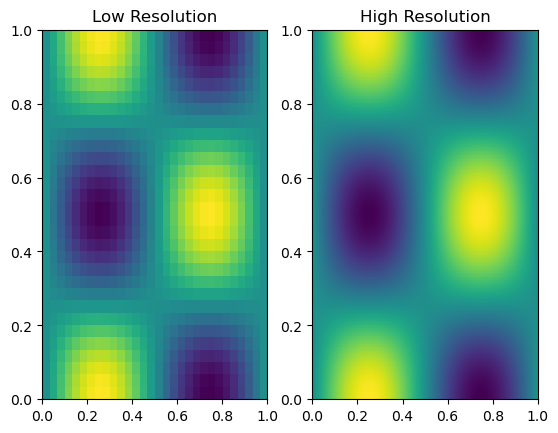

In [405]:
from scipy.interpolate import interp2d, RectBivariateSpline
m1, m2 = 30,30
n1, n2 = 100, 100
x_low = np.linspace(0, 1, m2)  # m2 columns
y_low = np.linspace(0, 1, m1)  # m1 rows
low_res_grid = np.sin(2 * np.pi * x_low) * np.cos(2 * np.pi * y_low[:, np.newaxis])  # Example low-res data

# Target high-res grid
x_high = np.linspace(0, 1, n2)  # n2 columns
y_high = np.linspace(0, 1, n1)  # n1 rows
interpolator = RectBivariateSpline(x_low, y_low, low_res_grid)
high_res_grid = interpolator(x_high, y_high)

print(low_res_grid, high_res_grid)
plt.subplot(1, 2, 1)
plt.imshow(low_res_grid, extent=[0, 1, 0, 1], origin="lower", aspect="auto")
plt.title("Low Resolution")

plt.subplot(1, 2, 2)
plt.imshow(high_res_grid, extent=[0, 1, 0, 1], origin="lower", aspect="auto")
plt.title("High Resolution")

plt.show()

In [615]:
s.A['m']['e'], s.A['m']['w'], s.A['m']['n'], s.A['m']['s'], s.A['m']['p'], s.b['u'], s.b['v']

(array([[1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ],
        [1.  , 0.01, 0.01, ..., 0.01, 0.  , 1.  ],
        [1.  , 0.01, 0.01, ..., 0.01, 0.  , 1.  ],
        ...,
        [1.  , 0.01, 0.01, ..., 0.01, 0.  , 1.  ],
        [1.  , 0.01, 0.01, ..., 0.01, 0.  , 1.  ],
        [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ]]),
 array([[1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ],
        [1.  , 0.  , 0.01, ..., 0.01, 0.01, 1.  ],
        [1.  , 0.  , 0.01, ..., 0.01, 0.01, 1.  ],
        ...,
        [1.  , 0.  , 0.01, ..., 0.01, 0.01, 1.  ],
        [1.  , 0.  , 0.01, ..., 0.01, 0.01, 1.  ],
        [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ]]),
 array([[1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ],
        [1.  , 0.  , 0.  , ..., 0.  , 0.  , 1.  ],
        [1.  , 0.01, 0.01, ..., 0.01, 0.01, 1.  ],
        ...,
        [1.  , 0.01, 0.01, ..., 0.01, 0.01, 1.  ],
        [1.  , 0.01, 0.01, ..., 0.01, 0.01, 1.  ],
        [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ]]),
 array([[1.  , 1.  , 1.  , ..., 1.  ,

dtype('float64')

In [637]:
s.A['m']['e'], s.A['m']['w'], s.A['m']['n'], s.A['m']['s'], s.A['m']['p'], s.b['u'], s.b['v']

(array([[1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ],
        [1.  , 0.01, 0.01, ..., 0.01, 0.  , 1.  ],
        [1.  , 0.01, 0.01, ..., 0.01, 0.  , 1.  ],
        ...,
        [1.  , 0.01, 0.01, ..., 0.01, 0.  , 1.  ],
        [1.  , 0.01, 0.01, ..., 0.01, 0.  , 1.  ],
        [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ]]),
 array([[1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ],
        [1.  , 0.  , 0.01, ..., 0.01, 0.01, 1.  ],
        [1.  , 0.  , 0.01, ..., 0.01, 0.01, 1.  ],
        ...,
        [1.  , 0.  , 0.01, ..., 0.01, 0.01, 1.  ],
        [1.  , 0.  , 0.01, ..., 0.01, 0.01, 1.  ],
        [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ]]),
 array([[1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ],
        [1.  , 0.  , 0.  , ..., 0.  , 0.  , 1.  ],
        [1.  , 0.01, 0.01, ..., 0.01, 0.01, 1.  ],
        ...,
        [1.  , 0.01, 0.01, ..., 0.01, 0.01, 1.  ],
        [1.  , 0.01, 0.01, ..., 0.01, 0.01, 1.  ],
        [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ]]),
 array([[1.  , 1.  , 1.  , ..., 1.  ,

In [729]:
s= NavierStokesSolver(u=None, L=1, n_cols=30, n_rows=30, Re=100, alpha_m=0.7, alpha_p=0.3, scheme='upwind')
s.solve(objective='m')


Iteration: 176, u_err: 0.00031067802894203263, v_err: 0.0002917437339018384, p_corr_err: 0.000365892994528333567
Finished with total error 0.0009683147573722045


(array([[ 0.   ,  1.   ,  1.   , ...,  1.   ,  1.   ,  0.   ],
        [ 0.   ,  0.239,  0.316, ...,  0.414,  0.283,  0.   ],
        [ 0.   , -0.008, -0.009, ...,  0.104,  0.043,  0.   ],
        ...,
        [ 0.   ,  0.   , -0.   , ...,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   , ...,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   , ...,  0.   ,  0.   ,  0.   ]]),
 0.00031067802894203263,
 array([[ 0.   ,  0.   ,  0.   , ...,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.158,  0.119, ..., -0.126, -0.181,  0.   ],
        [ 0.   ,  0.249,  0.225, ..., -0.314, -0.351,  0.   ],
        ...,
        [ 0.   , -0.   ,  0.   , ...,  0.   ,  0.   ,  0.   ],
        [ 0.   , -0.   , -0.   , ...,  0.   ,  0.   ,  0.   ],
        [ 0.   ,  0.   ,  0.   , ...,  0.   ,  0.   ,  0.   ]]),
 0.0002917437339018384,
 array([[ 0.   , -0.64 , -0.232, ...,  0.565,  1.099,  0.   ],
        [-0.64 , -0.64 , -0.232, ...,  0.565,  1.099,  1.099],
        [-0.337, -0.337, -0.206, ...,  

In [696]:
s.solve(objective='\phi')

(array([799.513, 798.539, 797.565, 796.59 , 795.615, 794.636, 793.653, 792.662, 791.659, 790.638, 789.591, 788.509, 787.38 , 786.188, 784.915, 783.534, 782.015, 780.314, 778.374, 776.118, 773.434, 770.159, 766.041, 760.669, 753.32 , 742.579, 725.276, 692.964, 618.593, 400.   , 798.539, 795.617, 792.695, 789.773, 786.847, 783.914, 780.968, 777.999, 774.995, 771.938, 768.808, 765.574, 762.202, 758.647, 754.852, 750.742, 746.226, 741.18 , 735.44 , 728.782, 720.893, 711.32 , 699.377, 683.986, 663.352, 634.301, 590.836, 520.95 , 400.   , 181.407, 797.565, 792.695, 787.826, 782.958, 778.086, 773.205, 768.305, 763.371, 758.383, 753.314, 748.127, 742.778, 737.208, 731.347, 725.101, 718.358, 710.968, 702.74 , 693.423, 682.677, 670.038, 654.85 , 636.161, 612.545, 581.801, 540.437, 482.818, 400.   , 279.05 , 107.036, 796.59 , 789.773, 782.958, 776.146, 769.334, 762.515, 755.676, 748.797, 741.853, 734.806, 727.609, 720.201, 712.507, 704.429, 695.851, 686.62 , 676.547, 665.39 , 652.833, 638.465, 62

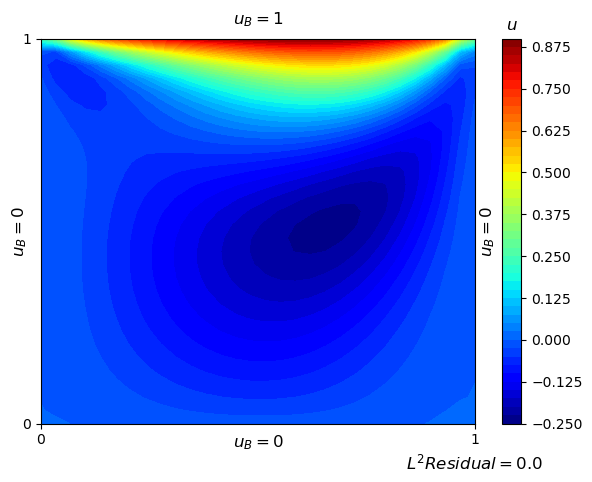

In [716]:
s.plot('u', num_contours=50, num_streamlines=0)

In [211]:
s.solve(objective='\phi')

(array([98.983, 97.491, 96.438, 95.696, 95.185, 94.838, 94.609, 94.466, 94.39 , 94.367, 94.387, 94.443, 94.529, 94.643, 94.78 , 94.94 , 95.122, 95.323, 95.538, 95.76 , 95.992, 96.235, 96.488, 96.742, 96.967, 97.07 , 96.758, 95.012, 87.899, 58.973, 97.538, 93.289, 90.068, 87.792, 86.2  , 85.112, 84.395, 83.955, 83.726, 83.664, 83.734, 83.913, 84.183, 84.532, 84.951, 85.434, 85.978, 86.581, 87.24 , 87.927, 88.648, 89.405, 90.191, 90.972, 91.641, 91.9  , 90.934, 86.561, 73.087, 37.178, 96.487, 90.358, 85.435, 81.64 , 78.882, 76.973, 75.709, 74.936, 74.539, 74.434, 74.56 , 74.871, 75.333, 75.923, 76.622, 77.421, 78.313, 79.294, 80.361, 81.501, 82.704, 83.963, 85.249, 86.475, 87.419, 87.532, 85.533, 78.581, 61.004, 26.201, 95.906, 88.525, 82.344, 77.426, 73.681, 70.926, 69.073, 67.929, 67.338, 67.176, 67.348, 67.782, 68.426, 69.241, 70.2  , 71.284, 72.482, 73.789, 75.201, 76.716, 78.315, 79.968, 81.604, 83.057, 83.959, 83.515, 80.095, 70.623, 51.316, 20.089, 95.629, 87.505, 80.454, 74.662, 

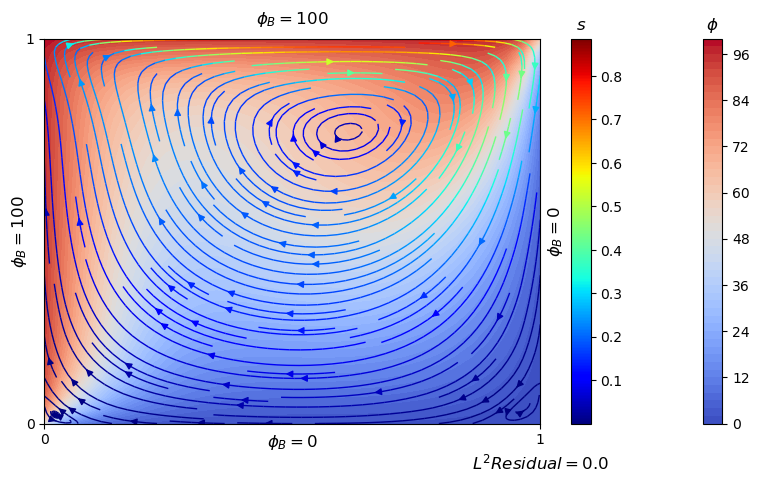

In [213]:
s.plot(objective='\phi', figsize=5, num_contours=50, num_streamlines=20)

In [ ]:
center_row = len(u) // 2
velocity_profile = u[center_row, :]

# Plot the velocity profile
plt.plot(velocity_profile)
plt.title("Velocity Profile Along Horizontal Centerline")
plt.xlabel("Horizontal Position")
plt.ylabel("Velocity")
plt.grid()
plt.show()

In [583]:
s.A['\\phi']['e'], s.A['\\phi']['w'], s.A['\\phi']['n'], s.A['\\phi']['s'], s.A['\\phi']['p']

(array([[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.061, 0.061, ..., 0.061, 0.   , 0.   ],
        [0.   , 0.064, 0.064, ..., 0.064, 0.   , 0.   ],
        ...,
        [0.   , 0.139, 0.139, ..., 0.139, 0.   , 0.   ],
        [0.   , 0.142, 0.142, ..., 0.142, 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ]]),
 array([[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.139, ..., 0.139, 0.139, 0.   ],
        [0.   , 0.   , 0.136, ..., 0.136, 0.136, 0.   ],
        ...,
        [0.   , 0.   , 0.061, ..., 0.061, 0.061, 0.   ],
        [0.   , 0.   , 0.058, ..., 0.058, 0.058, 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ]]),
 array([[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.061, 0.064, ..., 0.139, 0.142, 0.   ],
        ...,
        [0.   , 0.061, 0.064, ..., 0.139, 0.142, 0.   ],
        [0.   , 0.061, 0.064, ..., 0.139, 0.1

In [586]:
s.A['\\phi']['e'], s.A['\\phi']['w'], s.A['\\phi']['n'], s.A['\\phi']['s'], s.A['\\phi']['p']

(array([[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.061, 0.061, ..., 0.061, 0.   , 0.   ],
        [0.   , 0.064, 0.064, ..., 0.064, 0.   , 0.   ],
        ...,
        [0.   , 0.139, 0.139, ..., 0.139, 0.   , 0.   ],
        [0.   , 0.142, 0.142, ..., 0.142, 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ]]),
 array([[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.139, ..., 0.139, 0.139, 0.   ],
        [0.   , 0.   , 0.136, ..., 0.136, 0.136, 0.   ],
        ...,
        [0.   , 0.   , 0.061, ..., 0.061, 0.061, 0.   ],
        [0.   , 0.   , 0.058, ..., 0.058, 0.058, 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ]]),
 array([[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.061, 0.064, ..., 0.139, 0.142, 0.   ],
        ...,
        [0.   , 0.061, 0.064, ..., 0.139, 0.142, 0.   ],
        [0.   , 0.061, 0.064, ..., 0.139, 0.1

In [698]:

s = NavierStokesSolver(n_rows=100, n_cols=100, L=1,gamma=0.1, u=(lambda x, y:  (5 * y - 5 / 2), lambda x, y: -(5 * x - 5 / 2)), scheme='hybrid')
s.solve(solveSparse=True)


(array([99.992, 99.971, 99.946, ...,  0.053,  0.029,  0.008]),
 0.002714577462982083)

In [709]:
s.solve(solveSparse=True)

(array([699.942, 699.797, 699.624, ...,   0.373,   0.201,   0.058]),
 0.019002042240284043)

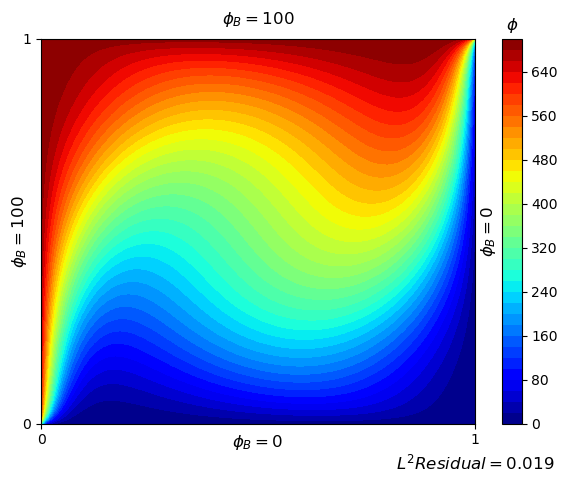

In [710]:
s.plot(objective='\\phi', num_streamlines=0)

In [55]:
s.x['u'][::-1][1:-1,1:-1]

array([[ 0.   ,  0.   ,  0.   , -0.   , -0.001, -0.002, -0.004, -0.005, -0.007, -0.008, -0.009, -0.01 , -0.011, -0.011, -0.012, -0.012, -0.011, -0.011, -0.01 , -0.009, -0.008, -0.007, -0.005, -0.004, -0.002, -0.001, -0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   , -0.   , -0.001, -0.003, -0.005, -0.008, -0.012, -0.015, -0.019, -0.022, -0.025, -0.028, -0.03 , -0.031, -0.032, -0.032, -0.031, -0.03 , -0.028, -0.025, -0.022, -0.019, -0.015, -0.011, -0.008, -0.005, -0.003, -0.001, -0.   ,  0.   ],
       [-0.   , -0.001, -0.003, -0.006, -0.009, -0.014, -0.019, -0.025, -0.03 , -0.035, -0.039, -0.043, -0.046, -0.049, -0.05 , -0.05 , -0.049, -0.046, -0.043, -0.039, -0.035, -0.03 , -0.024, -0.019, -0.014, -0.009, -0.005, -0.003, -0.001, -0.   ],
       [-0.   , -0.001, -0.004, -0.008, -0.014, -0.02 , -0.027, -0.034, -0.04 , -0.047, -0.053, -0.058, -0.062, -0.064, -0.066, -0.066, -0.064, -0.062, -0.058, -0.053, -0.047, -0.04 , -0.033, -0.027, -0.02 , -0.014, -0.008, -0.004, -0.001, -0.   ],
    